# Embedding Space Visualization

Do the learned/retrieved block representations preserve useful corpus structure?

The corpus mixes table facts, structured facts, narrative text, and policy rules. If the embedding representation is useful, `table_fact` and `structured_fact` blocks should form visibly different neighborhoods from narrative and policy-rule blocks because they were normalized from more structured sources. If they overlap heavily, retrieval may need stronger metadata and lexical signals.

This notebook projects block embeddings into 2D only when real `umap-learn` is installed. If UMAP is unavailable, it deliberately does not draw a fallback scatterplot, because a random projection would look scientific while saying almost nothing about embedding geometry.

In [2]:
import json
from pathlib import Path

ROOT = Path('..') if Path('../data/work/vectors.json').exists() else Path('.')
TABLE_DIR = ROOT / 'reports/tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)

payload = json.loads((ROOT / 'data/work/vectors.json').read_text(encoding='utf-8'))
blocks = payload['blocks']
vectors = payload['vectors']
len(blocks), len(vectors), len(vectors[0]) if vectors else 0


(18734, 18734, 256)

## Project Embeddings

Hypothesis: `table_fact` and `structured_fact` blocks should cluster apart from narrative and `policy_rule` blocks because table-derived rows carry repeated field names, row keys, and compact values. If UMAP does not show that separation, retrieval should rely more heavily on explicit metadata and lexical matching.

In [3]:
import random
import warnings
from collections import Counter, defaultdict

import numpy as np

paired_count = min(len(vectors), len(blocks))
max_points = 2000
max_per_block_type = 300
rng = random.Random(42)

grouped_indices = defaultdict(list)
for index, block in enumerate(blocks[:paired_count]):
    grouped_indices[block.get("block_type") or "unknown"].append(index)

selected_indices = []
for block_type, group in sorted(grouped_indices.items()):
    selected_indices.extend(rng.sample(group, min(len(group), max_per_block_type)))

if len(selected_indices) > max_points:
    selected_indices = rng.sample(selected_indices, max_points)

rng.shuffle(selected_indices)
indices = selected_indices
sample_vectors = [vectors[index] for index in indices]
sample_blocks = [blocks[index] for index in indices]
sample_block_type_counts = Counter(block.get("block_type") or "unknown" for block in sample_blocks)

projection_method = "umap"
projection_available = False
projection_warning = ""
coords = []
points = []

if not sample_vectors:
    projection_method = "no_data"
    projection_warning = "No vectors available for projection."

else:
    try:
        import umap

        reducer = umap.UMAP(
            n_components=2,
            random_state=42,
            metric="cosine",
            init="random",
            n_jobs=1,
        )

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="n_jobs value .* overridden to 1 by setting random_state",
                category=UserWarning,
            )

            coords = reducer.fit_transform(
                np.array(sample_vectors, dtype=float)
            ).tolist()

        projection_available = True

    except ImportError:
        projection_method = "umap_unavailable"
        projection_warning = (
            "umap-learn is not installed. No embedding projection is shown. "
            "Install with `pip install -e .[notebooks]`."
        )

if projection_available:
    for block, (x, y) in zip(sample_blocks, coords):
        points.append({
            "x": float(x),
            "y": float(y),
            "block_type": block.get("block_type") or "unknown",
            "title": block.get("title") or "",
            "document_id": block.get("document_id") or "",
        })

projection_method, len(points), dict(sorted(sample_block_type_counts.items())), projection_warning

('umap',
 1422,
 {'faq': 12,
  'list_item': 210,
  'narrative': 300,
  'policy_rule': 300,
  'structured_fact': 300,
  'table_fact': 300},
 '')

## Render UMAP Scatter Plot

Hypothesis: a real UMAP projection with a larger stratified sample should show partial block-type separation if embedding geometry captures source structure. The sample uses up to `2,000` blocks, capped at `300` per `block_type`, so a sparse display is not mistaken for a corpus-wide pattern. If table/structured facts still overlap with narrative/policy blocks, the visual result supports the silhouette finding that lexical and metadata signals matter more than pure vector geometry. If UMAP is unavailable, no scatterplot is shown because a fallback projection would not test this hypothesis.


Wrote sample metadata to ../reports/tables/embedding_projection_sample.json
Method: umap
Sample size: 1422
Sample by block_type: {'faq': 12, 'list_item': 210, 'narrative': 300, 'policy_rule': 300, 'structured_fact': 300, 'table_fact': 300}


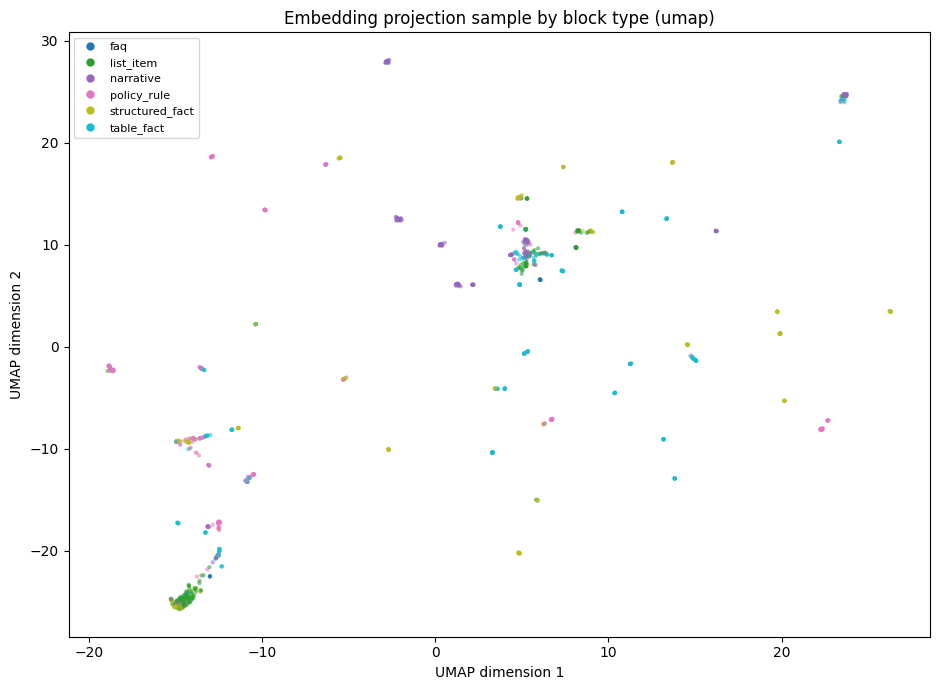

In [4]:
import matplotlib.pyplot as plt

summary_payload = {
    'method': projection_method,
    'sample_size': len(points),
    'sample_block_type_counts': dict(sorted(sample_block_type_counts.items())),
    'points': points[:2000],
    'warning': projection_warning,
}
(TABLE_DIR / 'embedding_projection_sample.json').write_text(json.dumps(summary_payload, indent=2), encoding='utf-8')
print(f'Wrote sample metadata to {TABLE_DIR / "embedding_projection_sample.json"}')
print(f'Method: {projection_method}')
print(f'Sample size: {len(points)}')
print('Sample by block_type:', dict(sorted(sample_block_type_counts.items())))

if projection_available:
    labels = sorted({point['block_type'] for point in points})
    color_map = {label: index for index, label in enumerate(labels)}
    xs = [point['x'] for point in points]
    ys = [point['y'] for point in points]
    colors = [color_map[point['block_type']] for point in points]

    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    scatter = ax.scatter(xs, ys, c=colors, cmap='tab10', s=9, alpha=0.55, linewidths=0)
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=scatter.cmap(scatter.norm(color_map[label])), markersize=7)
        for label in labels[:10]
    ]
    ax.legend(handles=handles, loc='best', frameon=True, fontsize=8)
    ax.set_title(f'Embedding projection sample by block type ({projection_method})')
    ax.set_xlabel('UMAP dimension 1')
    ax.set_ylabel('UMAP dimension 2')
    plt.tight_layout()
    plt.show()
else:
    print(projection_warning)

**Finding:** At the larger stratified sample size, block types remain visually interleaved rather than forming clean neighborhoods. This matches the earlier block-type silhouette score of `-0.0561`: the embedding model does not separate `table_fact`, `structured_fact`, `narrative`, and `policy_rule` blocks into distinct geometry. That is a meaningful retrieval finding, not a display artifact. It supports the retrieval ablation result that `hybrid_lexical_heavy` works best because row keys, country metadata, block type, and lexical matches carry signal that pure semantic similarity does not isolate.


## UMAP Failure-Risk View

Hypothesis: if failure is a geometric property of the embedding space, high-failure documents should cluster in a distinct region. If failures are uniformly scattered, it confirms that answer correctness loss is downstream of retrieval, not a property of which blocks the system can reach. Because evaluation labels are case-level while embeddings are block-level, this view aggregates benchmark outcomes to the source-document level and computes a continuous `failure_rate` for each sampled block's source document.

The first panel filters to benchmark-covered documents only, colors each point by document-level failure rate, and sizes points by the number of benchmark cases attached to the document. The second panel bins UMAP space into a grid and shows the mean failure rate per populated cell. This avoids the coarse `has_failure`/`all_correct` label where a document with `1/20` failures looked identical to one with `15/20` failures.


Sample by benchmark outcome: {'all_correct': 300, 'has_failure': 844, 'not_in_benchmark': 278}
Benchmark-only failure rate summary: {'n_points': 1144, 'mean': 0.0746, 'median': 0.0714, 'max': 0.2667}
Updated sample metadata with benchmark failure rates: ../reports/tables/embedding_projection_sample.json
Failure-rate heatmap populated cells: 55/400 (min n=3)


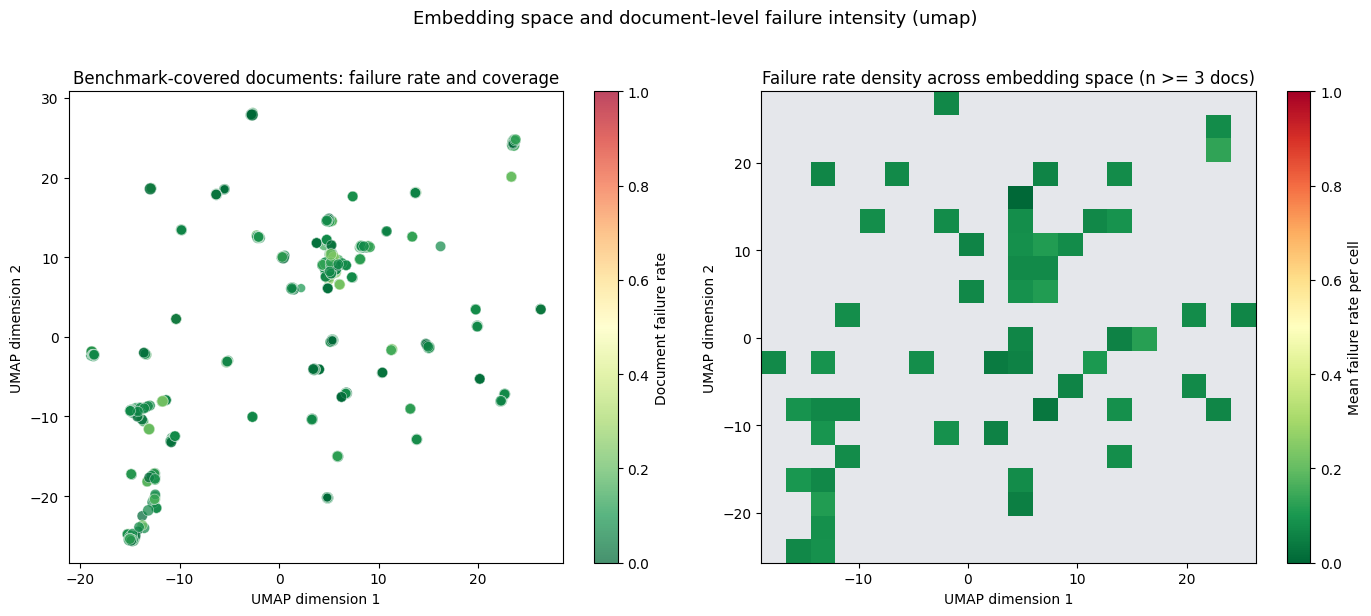

In [5]:
from scipy.stats import binned_statistic_2d

evaluation_path = ROOT / 'data/work/evaluation/latest-evaluation.json'
document_outcomes = {}
if evaluation_path.exists():
    evaluation_payload = json.loads(evaluation_path.read_text(encoding='utf-8'))
    for result in evaluation_payload.get('results', []):
        if result.get('should_refuse'):
            continue
        for document_id in result.get('expected_document_ids') or []:
            outcome = document_outcomes.setdefault(document_id, {'correct': 0, 'incorrect': 0})
            if result.get('answer_correct'):
                outcome['correct'] += 1
            else:
                outcome['incorrect'] += 1

for point in points:
    outcome = document_outcomes.get(point['document_id'])
    total_cases = (outcome or {}).get('correct', 0) + (outcome or {}).get('incorrect', 0)
    incorrect_cases = (outcome or {}).get('incorrect', 0)
    point['benchmark_case_count'] = total_cases
    point['failure_rate'] = incorrect_cases / total_cases if total_cases else None
    if not outcome:
        point['benchmark_outcome'] = 'not_in_benchmark'
    elif incorrect_cases:
        point['benchmark_outcome'] = 'has_failure'
    else:
        point['benchmark_outcome'] = 'all_correct'

outcome_counts = Counter(point.get('benchmark_outcome', 'not_in_benchmark') for point in points)
benchmark_points = [point for point in points if point.get('failure_rate') is not None]
failure_rates = [point['failure_rate'] for point in benchmark_points]
print('Sample by benchmark outcome:', dict(sorted(outcome_counts.items())))
if failure_rates:
    print(
        'Benchmark-only failure rate summary:',
        {
            'n_points': len(benchmark_points),
            'mean': round(float(np.mean(failure_rates)), 4),
            'median': round(float(np.median(failure_rates)), 4),
            'max': round(float(np.max(failure_rates)), 4),
        },
    )

summary_payload = {
    'method': projection_method,
    'sample_size': len(points),
    'sample_block_type_counts': dict(sorted(sample_block_type_counts.items())),
    'sample_benchmark_outcome_counts': dict(sorted(outcome_counts.items())),
    'points': points[:2000],
    'warning': projection_warning,
}
(TABLE_DIR / 'embedding_projection_sample.json').write_text(json.dumps(summary_payload, indent=2), encoding='utf-8')
print(f'Updated sample metadata with benchmark failure rates: {TABLE_DIR / "embedding_projection_sample.json"}')

if projection_available:
    fig, axes = plt.subplots(1, 2, figsize=(14.0, 6.0))
    cmap = plt.get_cmap('RdYlGn_r').copy()
    cmap.set_bad('#e5e7eb')

    ax = axes[0]
    if benchmark_points:
        xs = np.array([point['x'] for point in benchmark_points])
        ys = np.array([point['y'] for point in benchmark_points])
        rates = np.array([point['failure_rate'] for point in benchmark_points])
        sizes = np.array([max(18, min(point.get('benchmark_case_count', 0) * 4, 120)) for point in benchmark_points])
        scatter = ax.scatter(
            xs,
            ys,
            c=rates,
            cmap=cmap,
            vmin=0,
            vmax=1,
            s=sizes,
            alpha=0.72,
            linewidths=0.35,
            edgecolors='white',
        )
        plt.colorbar(scatter, ax=ax, label='Document failure rate')
    else:
        ax.text(0.5, 0.5, 'No benchmark-labeled documents in sample', ha='center', va='center')
    ax.set_title('Benchmark-covered documents: failure rate and coverage')
    ax.set_xlabel('UMAP dimension 1')
    ax.set_ylabel('UMAP dimension 2')

    ax2 = axes[1]
    if benchmark_points:
        stat, x_edges, y_edges, _ = binned_statistic_2d(
            xs,
            ys,
            rates,
            statistic='mean',
            bins=20,
        )
        count_stat, _, _, _ = binned_statistic_2d(
            xs,
            ys,
            rates,
            statistic='count',
            bins=[x_edges, y_edges],
        )
        stat[count_stat < 3] = np.nan
        populated_cells = int(np.isfinite(stat).sum())
        print(f'Failure-rate heatmap populated cells: {populated_cells}/{stat.size} (min n=3)')
        image = ax2.pcolormesh(
            x_edges,
            y_edges,
            stat.T,
            cmap=cmap,
            vmin=0,
            vmax=1,
            shading='auto',
        )
        plt.colorbar(image, ax=ax2, label='Mean failure rate per cell')
    else:
        ax2.text(0.5, 0.5, 'No benchmark-labeled documents in sample', ha='center', va='center')
    ax2.set_title('Failure rate density across embedding space (n >= 3 docs)')
    ax2.set_xlabel('UMAP dimension 1')
    ax2.set_ylabel('UMAP dimension 2')

    plt.suptitle(f'Embedding space and document-level failure intensity ({projection_method})', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(projection_warning)


**Finding:** The continuous failure-rate view shows that failures are not a distinct geometric property of the embedding space. High- and low-failure documents are broadly interleaved across the projection, while the dense bottom-left region around `(-13, -22)` is dominated by benchmark-missing or all-correct structured reference documents. That visual pattern corroborates the quantitative result that retrieval recall is very high while answer correctness still lags: documents that fail are not isolated in a remote vector-space neighborhood.

The useful signal is intensity rather than the coarse `has_failure` label. A document with one failed case no longer looks identical to a document with many failed cases, and the heatmap makes the central conclusion easier to review: residual errors are more consistent with answer synthesis, citation anchoring, and question-specific retrieval behavior than with broad embedding geometry.
